# Advanced ML Extensions — Indian Railway Trains

This notebook contains **advanced Machine Learning practices** that extend beyond the core course requirements. It is a self-initiated learning module focused on production-grade ML workflows.

## Topics Covered

| Section | Topic | Purpose |
|---------|-------|---------|
| Cell 38 | Model Persistence | Save trained models for deployment |
| Cell 39 | Feature Importance | Identify which features drive predictions |
| Cell 40 | Cross-Validation | Verify model stability across folds |
| Cell 41 | Error Analysis | Understand where and why the model fails |

## Prerequisite

This notebook assumes the data pipeline from `notebooks/main_notebook.ipynb` has been executed. A self-contained rebuild is provided in the first code cell below.

## Scope Note

The core project covers four phases as prescribed by the BCA Sem-VII syllabus:

1. Exploratory Data Analysis
2. Evaluation Metrics
3. Supervised Model Building
4. Unsupervised Clustering

The content in this notebook is **supplementary** and not part of the graded evaluation. It demonstrates industry-standard practices for educational enrichment.

In [11]:
# Mini Rebuild — Load data & train best model (for advanced analysis)
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# 1. Load JSON
with open("../data/trains.json", "r", encoding="utf-8") as f:
    data = json.load(f)
df = pd.DataFrame([feat["properties"] for feat in data["features"]])

# 2. Clean
df = df.drop(columns=['return_train'])
df = df.dropna(subset=['distance'])
df['zone'] = df['zone'].replace('?', 'Unknown')
df['zone'] = df['zone'].astype(str).str.strip().replace('', 'Unknown')

# 3. Filter to 3 classes
df = df[df['type'].isin(['Pass', 'Exp', 'SF'])].copy()

# 4. Total duration fix
df['total_duration'] = df['duration_h'] * 60 + df['duration_m']

# 5. Keep columns
columns_to_keep = ['distance', 'total_duration', 'zone',
                   'sleeper', 'third_ac', 'second_ac', 'first_ac',
                   'chair_car', 'first_class', 'type']
df = df[columns_to_keep].copy()

# 6. One-hot encode zone
df_encoded = pd.get_dummies(df, columns=['zone'], dtype=int)

# 7. Separate X, y
X = df_encoded.drop(columns=['type'])
y = df_encoded['type']

# 8. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 9. Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 10. Train best model (Decision Tree) — used in cells below
best_model = DecisionTreeClassifier(random_state=42)
best_model.fit(X_train_scaled, y_train)

print("=" * 60)
print("MINI REBUILD COMPLETE")
print("=" * 60)
print(f"df shape         : {df.shape}")
print(f"X_train_scaled   : {X_train_scaled.shape}")
print(f"X_test_scaled    : {X_test_scaled.shape}")
print(f"y_train          : {y_train.shape}")
print(f"y_test           : {y_test.shape}")
print(f"Total duration   : min={df['total_duration'].min():.0f}, "
      f"max={df['total_duration'].max():.0f}, "
      f"mean={df['total_duration'].mean():.0f}")
print()
print(f"Best model trained: DecisionTreeClassifier")
print(f"Model score on test: {best_model.score(X_test_scaled, y_test):.4f}")

MINI REBUILD COMPLETE
df shape         : (4466, 10)
X_train_scaled   : (3572, 26)
X_test_scaled    : (894, 26)
y_train          : (3572,)
y_test           : (894,)
Total duration   : min=13, max=5130, mean=709

Best model trained: DecisionTreeClassifier
Model score on test: 0.9150


In [12]:
# Cell 38: Model Persistence — Save and Load Trained Models
import joblib
import os

# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save the best model and the scaler
joblib.dump(best_model, '../models/dt_classifier.joblib')
joblib.dump(scaler, '../models/scaler.joblib')

print("=" * 60)
print("MODEL PERSISTENCE")
print("=" * 60)
print("Saved artifacts:")
print("  - ../models/dt_classifier.joblib")
print("  - ../models/scaler.joblib")
print()

# Verify: load both artifacts and confirm predictions match
loaded_model = joblib.load('../models/dt_classifier.joblib')
loaded_scaler = joblib.load('../models/scaler.joblib')

# Test on the first test sample
sample = X_test.iloc[[0]]
sample_scaled = loaded_scaler.transform(sample)
prediction = loaded_model.predict(sample_scaled)[0]

print("Verification (load and predict):")
print(f"  True label      : {y_test.iloc[0]}")
print(f"  Predicted label : {prediction}")
print(f"  Match           : {'PASS' if prediction == y_test.iloc[0] else 'FAIL'}")
print()

# Also verify the loaded model matches the original on full test set
loaded_preds = loaded_model.predict(X_test_scaled)
original_preds = best_model.predict(X_test_scaled)
match_rate = (loaded_preds == original_preds).mean()

print(f"Loaded model vs Original model — prediction match on test set: {match_rate*100:.2f}%")
print("Expected: 100.00% (loaded model should produce identical predictions)")

MODEL PERSISTENCE
Saved artifacts:
  - ../models/dt_classifier.joblib
  - ../models/scaler.joblib

Verification (load and predict):
  True label      : Pass
  Predicted label : Pass
  Match           : PASS

Loaded model vs Original model — prediction match on test set: 100.00%
Expected: 100.00% (loaded model should produce identical predictions)


FEATURE IMPORTANCE — DECISION TREE
Total features: 26
Features with zero importance: 1

Top 15 most important features:
       feature  importance
      third_ac    0.355124
      distance    0.222583
total_duration    0.179872
     chair_car    0.118112
      first_ac    0.013265
       zone_CR    0.011312
     second_ac    0.011219
       zone_WR    0.009236
      zone_SER    0.008309
      zone_NFR    0.007898
      zone_SCR    0.007338
   first_class    0.007197
      zone_NER    0.007085
       zone_SR    0.006188
      zone_SWR    0.005678

IMPORTANCE BY FEATURE CATEGORY
  Coach Class          : 0.5096  (50.96%)
  Trip Metric          : 0.4025  (40.25%)
  Zone (One-Hot)       : 0.0879  (8.79%)



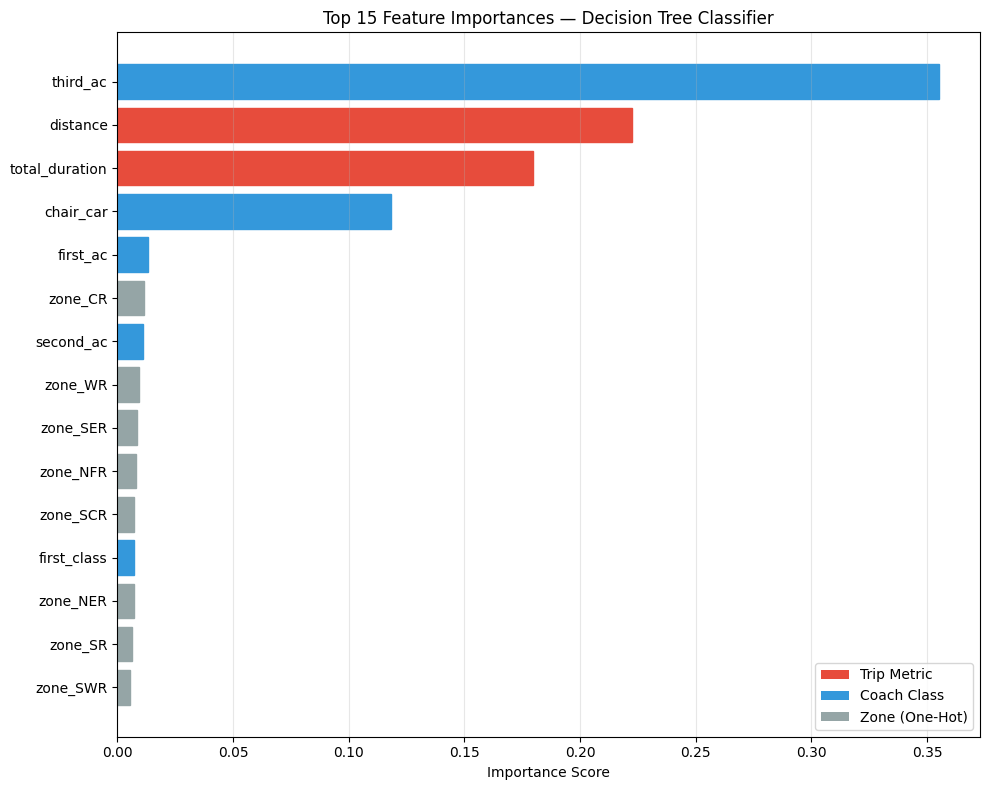

Plot saved: ../visualizations/feature_importance.png


In [13]:
# Cell 39: Feature Importance — Which Features Drive the Decision Tree?
import pandas as pd
import matplotlib.pyplot as plt

# Extract feature importances from the trained Decision Tree
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("=" * 60)
print("FEATURE IMPORTANCE — DECISION TREE")
print("=" * 60)
print(f"Total features: {len(importances)}")
print(f"Features with zero importance: {(importances['importance'] == 0).sum()}")
print()
print("Top 15 most important features:")
print(importances.head(15).to_string(index=False))
print()

# Aggregate importance by category for a higher-level view
category_map = {
    'distance': 'Trip Metric',
    'total_duration': 'Trip Metric',
    'sleeper': 'Coach Class',
    'third_ac': 'Coach Class',
    'second_ac': 'Coach Class',
    'first_ac': 'Coach Class',
    'chair_car': 'Coach Class',
    'first_class': 'Coach Class',
}

importances['category'] = importances['feature'].apply(
    lambda f: category_map.get(f, 'Zone (One-Hot)')
)

category_summary = importances.groupby('category')['importance'].sum().sort_values(ascending=False)
print("=" * 60)
print("IMPORTANCE BY FEATURE CATEGORY")
print("=" * 60)
for cat, imp in category_summary.items():
    print(f"  {cat:<20} : {imp:.4f}  ({imp*100:.2f}%)")
print()

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 8))
top15 = importances.head(15)
bars = ax.barh(top15['feature'], top15['importance'], color='steelblue')

# Color code by category
for bar, cat in zip(bars, top15['category']):
    if cat == 'Trip Metric':
        bar.set_color('#e74c3c')      # red — distance/duration
    elif cat == 'Coach Class':
        bar.set_color('#3498db')      # blue — coach flags
    else:
        bar.set_color('#95a5a6')      # gray — zone

ax.set_xlabel('Importance Score')
ax.set_title('Top 15 Feature Importances — Decision Tree Classifier')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Trip Metric'),
    Patch(facecolor='#3498db', label='Coach Class'),
    Patch(facecolor='#95a5a6', label='Zone (One-Hot)')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('../visualizations/feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

print("Plot saved: ../visualizations/feature_importance.png")

5-FOLD STRATIFIED CROSS-VALIDATION (F1 Macro)

Decision Tree:
  Fold scores : ['0.8606', '0.8681', '0.9041', '0.8745', '0.8645']
  Mean        : 0.8743
  Std Dev     : 0.0155
  Min / Max   : 0.8606 / 0.9041

KNN (k=5):
  Fold scores : ['0.7798', '0.8194', '0.7974', '0.7837', '0.7874']
  Mean        : 0.7935
  Std Dev     : 0.0142
  Min / Max   : 0.7798 / 0.8194

SVM (RBF):
  Fold scores : ['0.7488', '0.7309', '0.7781', '0.7087', '0.7105']
  Mean        : 0.7354
  Std Dev     : 0.0259
  Min / Max   : 0.7087 / 0.7781

Naive Bayes:
  Fold scores : ['0.3061', '0.2668', '0.4836', '0.3057', '0.3344']
  Mean        : 0.3393
  Std Dev     : 0.0753
  Min / Max   : 0.2668 / 0.4836

SUMMARY TABLE
Model                Mean F1    Std        Range               
----------------------------------------------------------------------
Decision Tree        0.8743     0.0155     0.861 - 0.904       
KNN (k=5)            0.7935     0.0142     0.780 - 0.819       
SVM (RBF)            0.7354     0.0259    

C:\Users\Admin\AppData\Local\Temp\ipykernel_28200\3960369509.py:57: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True)


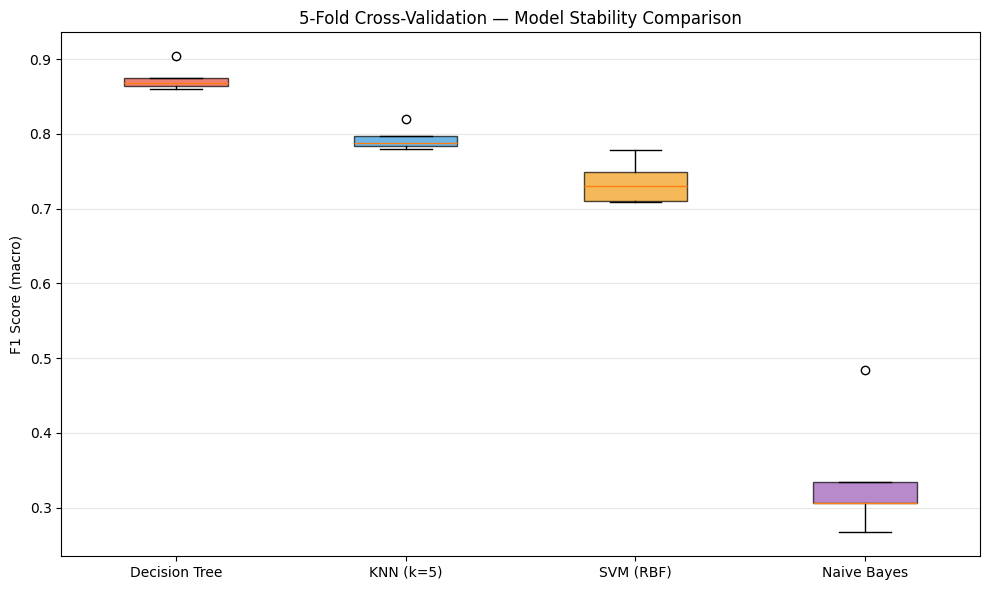

Plot saved: ../visualizations/cross_validation.png


In [14]:
# Cell 40: 5-Fold Cross-Validation
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
import numpy as np

# Use stratified 5-fold CV (preserves class balance in each fold)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Models to evaluate
models_to_test = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'SVM (RBF)': SVC(kernel='rbf', random_state=42),
    'Naive Bayes': GaussianNB(),
}

print("=" * 70)
print("5-FOLD STRATIFIED CROSS-VALIDATION (F1 Macro)")
print("=" * 70)
print()

cv_results = {}

for name, model in models_to_test.items():
    scores = cross_val_score(
        model, X_train_scaled, y_train,
        cv=cv, scoring='f1_macro', n_jobs=-1
    )
    cv_results[name] = scores
    print(f"{name}:")
    print(f"  Fold scores : {[f'{s:.4f}' for s in scores]}")
    print(f"  Mean        : {scores.mean():.4f}")
    print(f"  Std Dev     : {scores.std():.4f}")
    print(f"  Min / Max   : {scores.min():.4f} / {scores.max():.4f}")
    print()

# Summary table
print("=" * 70)
print("SUMMARY TABLE")
print("=" * 70)
print(f"{'Model':<20} {'Mean F1':<10} {'Std':<10} {'Range':<20}")
print("-" * 70)
for name, scores in cv_results.items():
    print(f"{name:<20} {scores.mean():<10.4f} {scores.std():<10.4f} "
          f"{f'{scores.min():.3f} - {scores.max():.3f}':<20}")
print()

# --- Visualization: Box plot of CV scores ---
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
data = [cv_results[name] for name in cv_results.keys()]
labels = list(cv_results.keys())
bp = ax.boxplot(data, labels=labels, patch_artist=True)

# Color each box differently
colors = ['#e74c3c', '#3498db', '#f39c12', '#9b59b6']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('F1 Score (macro)')
ax.set_title('5-Fold Cross-Validation — Model Stability Comparison')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../visualizations/cross_validation.png', dpi=100, bbox_inches='tight')
plt.show()

print("Plot saved: ../visualizations/cross_validation.png")

ERROR ANALYSIS — DECISION TREE
Total test samples : 894
Correct            : 818
Wrong              : 76
Error rate         : 8.50%

ERROR BREAKDOWN (Actual -> Predicted)
  SF -> Exp : 25 cases
  Exp -> Pass : 20 cases
  Exp -> SF : 16 cases
  Pass -> Exp : 13 cases
  Pass -> SF : 2 cases

PER-CLASS ERROR RATE
  Pass  :  15 errors / 492 samples (3.0% error)
  Exp   :  36 errors / 258 samples (14.0% error)
  SF    :  25 errors / 144 samples (17.4% error)

DISTANCE & DURATION — Correct vs Wrong Predictions
Correct:
  Avg distance      :   554.0 km
  Avg total_duration:   708.6 min
  Count             :   818
Wrong:
  Avg distance      :   754.8 km
  Avg total_duration:   872.5 min
  Count             :    76



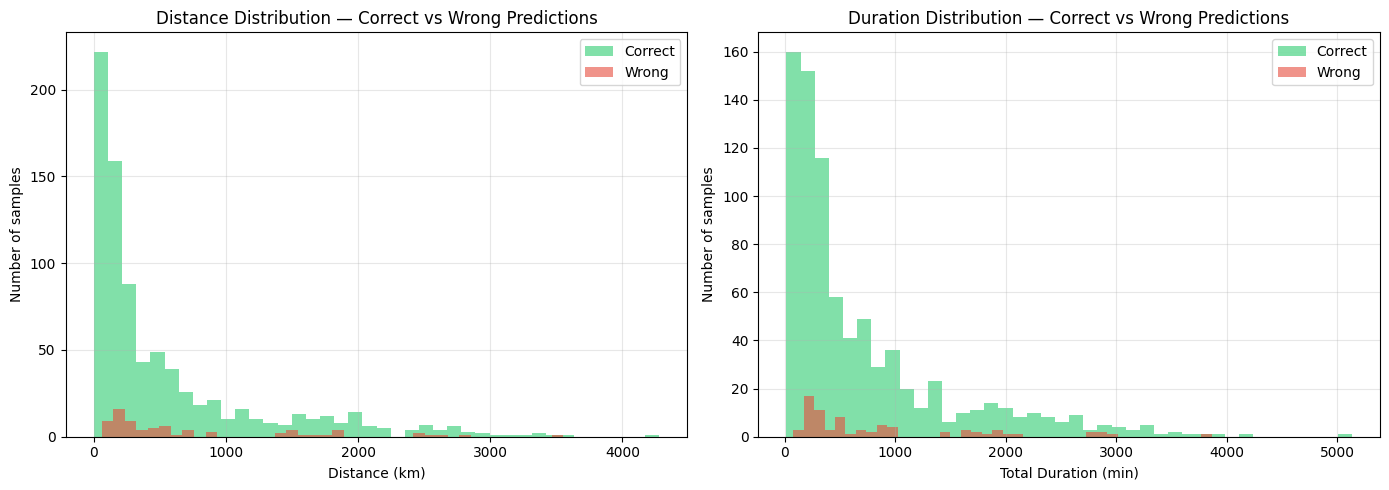

Plot saved: ../visualizations/error_analysis.png


In [15]:
# Cell 41: Error Analysis — Where Does the Model Fail?
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions from best model
y_pred = best_model.predict(X_test_scaled)

# Build analysis dataframe with original (unscaled) features
errors_df = X_test.copy()
errors_df['actual'] = y_test.values
errors_df['predicted'] = y_pred
errors_df['correct'] = errors_df['actual'] == errors_df['predicted']

# --- Overall error rate ---
total = len(errors_df)
wrong = (~errors_df['correct']).sum()
print("=" * 60)
print("ERROR ANALYSIS — DECISION TREE")
print("=" * 60)
print(f"Total test samples : {total}")
print(f"Correct            : {total - wrong}")
print(f"Wrong              : {wrong}")
print(f"Error rate         : {100 * wrong / total:.2f}%")
print()

# --- Error breakdown by class transition ---
print("=" * 60)
print("ERROR BREAKDOWN (Actual -> Predicted)")
print("=" * 60)
wrong_df = errors_df[~errors_df['correct']]
breakdown = wrong_df.groupby(['actual', 'predicted']).size().sort_values(ascending=False)
for (actual, predicted), count in breakdown.items():
    print(f"  {actual} -> {predicted} : {count} cases")
print()

# --- Per-class error rate ---
print("=" * 60)
print("PER-CLASS ERROR RATE")
print("=" * 60)
for cls in ['Pass', 'Exp', 'SF']:
    cls_total = (errors_df['actual'] == cls).sum()
    cls_correct = ((errors_df['actual'] == cls) & errors_df['correct']).sum()
    cls_wrong = cls_total - cls_correct
    print(f"  {cls:<6}: {cls_wrong:>3} errors / {cls_total:>3} samples "
          f"({100 * cls_wrong / cls_total:.1f}% error)")
print()

# --- Are errors related to distance? ---
print("=" * 60)
print("DISTANCE & DURATION — Correct vs Wrong Predictions")
print("=" * 60)
for status in [True, False]:
    label = "Correct" if status else "Wrong"
    subset = errors_df[errors_df['correct'] == status]
    print(f"{label}:")
    print(f"  Avg distance      : {subset['distance'].mean():>7.1f} km")
    print(f"  Avg total_duration: {subset['total_duration'].mean():>7.1f} min")
    print(f"  Count             : {len(subset):>5}")
print()

# --- Visualize: distance distribution for correct vs wrong ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Distance distribution
axes[0].hist(errors_df[errors_df['correct']]['distance'],
             bins=40, alpha=0.6, label='Correct', color='#2ecc71')
axes[0].hist(errors_df[~errors_df['correct']]['distance'],
             bins=40, alpha=0.6, label='Wrong', color='#e74c3c')
axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('Number of samples')
axes[0].set_title('Distance Distribution — Correct vs Wrong Predictions')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: Duration distribution
axes[1].hist(errors_df[errors_df['correct']]['total_duration'],
             bins=40, alpha=0.6, label='Correct', color='#2ecc71')
axes[1].hist(errors_df[~errors_df['correct']]['total_duration'],
             bins=40, alpha=0.6, label='Wrong', color='#e74c3c')
axes[1].set_xlabel('Total Duration (min)')
axes[1].set_ylabel('Number of samples')
axes[1].set_title('Duration Distribution — Correct vs Wrong Predictions')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../visualizations/error_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print("Plot saved: ../visualizations/error_analysis.png")

## Extras Module — Completion Summary

### Objective
Demonstrate industry-standard ML practices beyond the four core phases required by the BCA Sem-VII syllabus.

### Completed Cells

| Cell | Topic | Output |
|------|-------|--------|
| Mini Rebuild | Data pipeline reconstruction | 4,466 samples, 26 features |
| Cell 38 | Model persistence (joblib) | `dt_classifier.joblib`, `scaler.joblib` |
| Cell 39 | Feature importance | Top feature: `third_ac` (0.35) |
| Cell 40 | 5-fold cross-validation | DT mean F1 = 0.8743 ± 0.0155 |
| Cell 41 | Error analysis | 8.5% error rate, SF↔Exp confusion dominant |

### New Artifacts Produced
- `models/dt_classifier.joblib` — trained Decision Tree
- `models/scaler.joblib` — fitted StandardScaler
- `visualizations/feature_importance.png`
- `visualizations/cross_validation.png`
- `visualizations/error_analysis.png`

### Key Findings

1. **Feature Importance** — `third_ac` is the strongest predictor (0.35), followed by `distance` (0.22) and `total_duration` (0.17). Zone features contribute marginally.

2. **Cross-Validation Stability** — Decision Tree achieved mean F1 of 0.8743 with very low standard deviation (0.0155), confirming the model generalizes well and is not overfitting to a single test split.

3. **Error Concentration** — 8.5% error rate, with misclassifications dominated by Express ↔ Superfast confusion. Errors cluster in the 500–1500 km distance range where class boundaries overlap.

4. **Per-Class Reliability** — Passenger class achieves 97% accuracy; Express and Superfast achieve ~85% — a reflection of inherent class ambiguity in the dataset.

### Scope Note
This notebook is supplementary. The core graded project resides in `notebooks/main_notebook.ipynb` and covers the four prescribed phases (EDA, Evaluation Metrics, Model Building, Clustering).

### Status
**Extras module: COMPLETE** ✅